#### Cohort Retention Heatmaps & Curves

**Goal**  
- Build classic cohort retention heatmaps (D1, D7, D30)  
- Show retention trends over time by install month  
- Compare Variant A vs B (if you added variant later)  
- Highlight long-term retention decay & opportunities

**Input**  
`../data/raw/player_journey_50k.csv`

**Output**  
- Heatmaps (seaborn)  
- Retention curves by cohort (Plotly)

#### Imports & load data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Load Phase 1 data
df = pd.read_csv("../data/raw/player_journey_50k.csv")
df['install_date'] = pd.to_datetime(df['install_date'])

print("Data loaded")
print("Shape:", df.shape)
print("Install date range:", df['install_date'].min().date(), "–", df['install_date'].max().date())

Data loaded
Shape: (50000, 16)
Install date range: 2023-01-01 – 2023-02-04


#### Create cohort month & retention flags

In [7]:
df['cohort_month'] = df['install_date'].dt.to_period('M').astype(str)

# Aggregate by cohort month
cohort_table = df.groupby('cohort_month', as_index=False).agg({
    'player_id': 'count',
    'd1_return': ['sum', 'mean'],
    'd7_return': ['sum', 'mean'],
    'd30_return': ['sum', 'mean']
})

# Flatten multi-index columns
cohort_table.columns = [
    'cohort_month',
    'cohort_size',
    'd1_return_count', 'd1_return_pct',
    'd7_return_count', 'd7_return_pct',
    'd30_return_count', 'd30_return_pct'
]

# Convert means to percentages
for col in ['d1_return_pct', 'd7_return_pct', 'd30_return_pct']:
    cohort_table[col] = (cohort_table[col] * 100).round(1)

# Sort by cohort month (newest first)
cohort_table = cohort_table.sort_values('cohort_month', ascending=False).reset_index(drop=True)

print("Cohort retention table (with absolute counts and %)")
display(cohort_table.style.format({
    'cohort_size': '{:,}',
    'd1_return_count': '{:,}',
    'd7_return_count': '{:,}',
    'd30_return_count': '{:,}'
}))

Cohort retention table (with absolute counts and %)


,cohort_month,cohort_size,d1_return_count,d1_return_pct,d7_return_count,d7_return_pct,d30_return_count,d30_return_pct
0,2023-02,"5,360","1,047",19.500000,522,9.700000,199,3.700000
1,2023-01,"44,640","9,181",20.600000,"4,555",10.200000,"1,880",4.200000


#### D7 Retention Cohort Heatmap

Columns in cohort_table:
['cohort_month', 'cohort_size', 'd1_return_count', 'd1_return_pct', 'd7_return_count', 'd7_return_pct', 'd30_return_count', 'd30_return_pct']


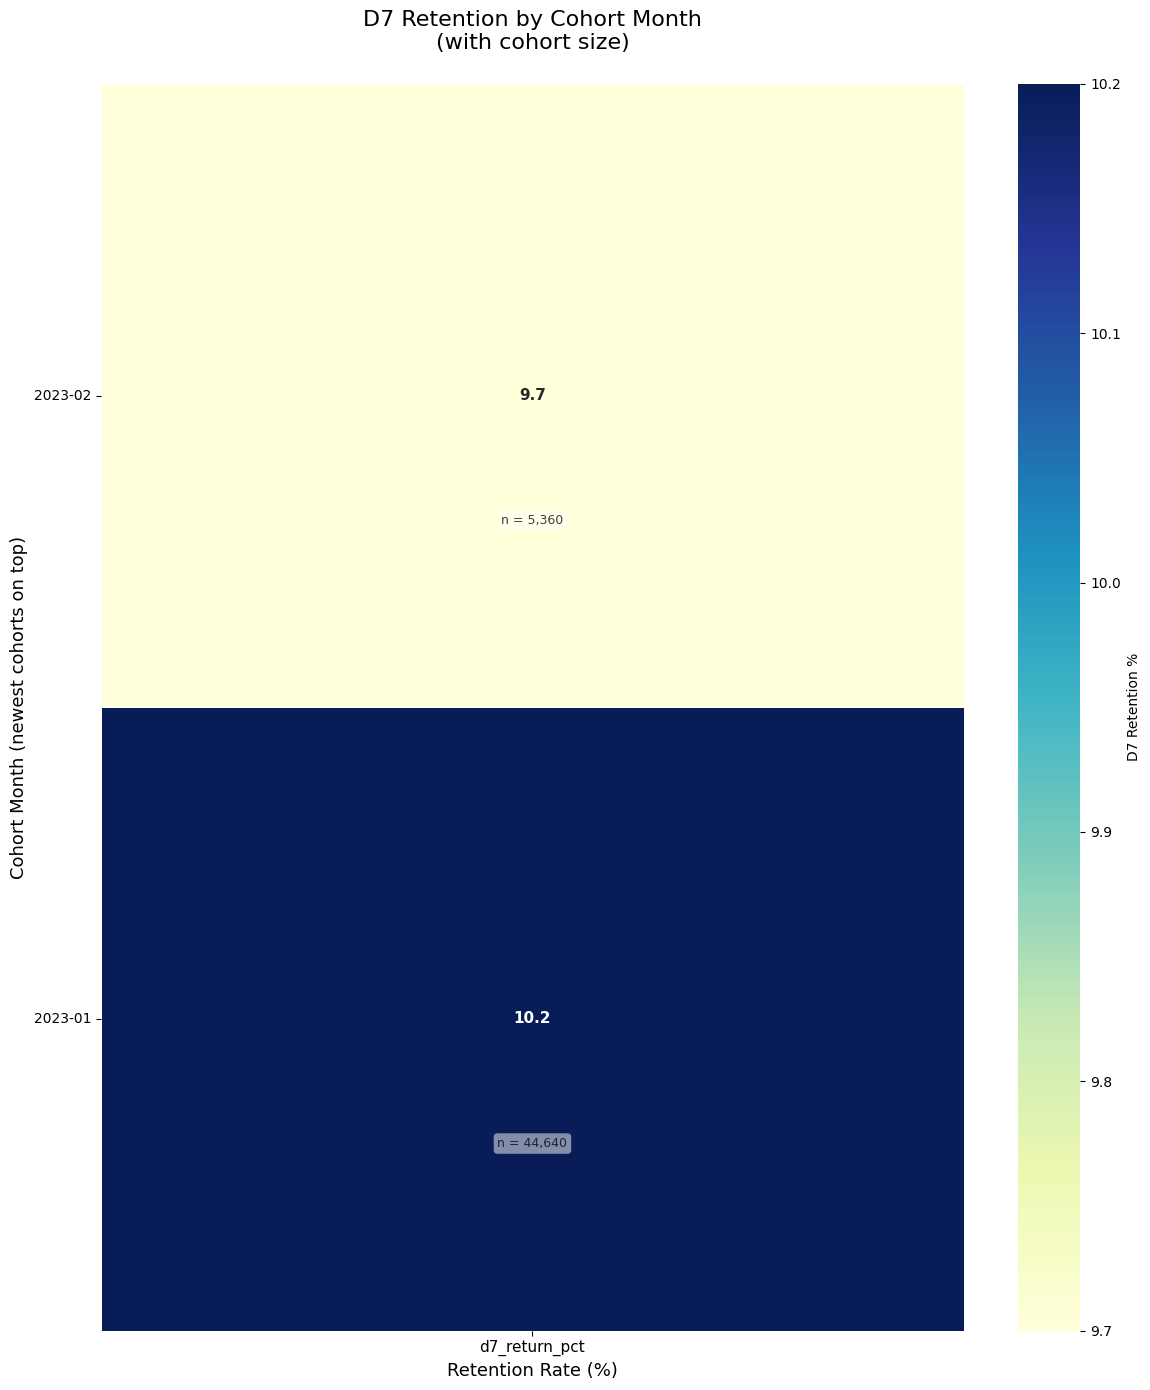

In [13]:
# Safety check: confirm column exists
print("Columns in cohort_table:")
print(cohort_table.columns.tolist())

# Pivot D7 retention % (no columns= needed for single metric)
heatmap_data = cohort_table.pivot_table(
    index='cohort_month',
    values='d7_return_pct',
    aggfunc='mean'          # safe even if one value per month
).sort_index(ascending=False)  # newest cohorts on top

# Cohort size for text labels
size_data = cohort_table.set_index('cohort_month')['cohort_size']

plt.figure(figsize=(12, 14))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.6,
    cbar_kws={'label': 'D7 Retention %'},
    annot_kws={'size': 11, 'weight': 'bold'}
)

# Add cohort size text below each percentage
for i, month in enumerate(heatmap_data.index):
    size_val = size_data.loc[month]
    ax.text(0.5, i + 0.7, f'n = {size_val:,}', 
            color='black', ha='center', va='center', fontsize=9, alpha=0.75,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.3'))

plt.title('D7 Retention by Cohort Month\n(with cohort size)', fontsize=16, pad=25)
plt.ylabel('Cohort Month (newest cohorts on top)', fontsize=13)
plt.xlabel('Retention Rate (%)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

#### Retention curves by cohort month

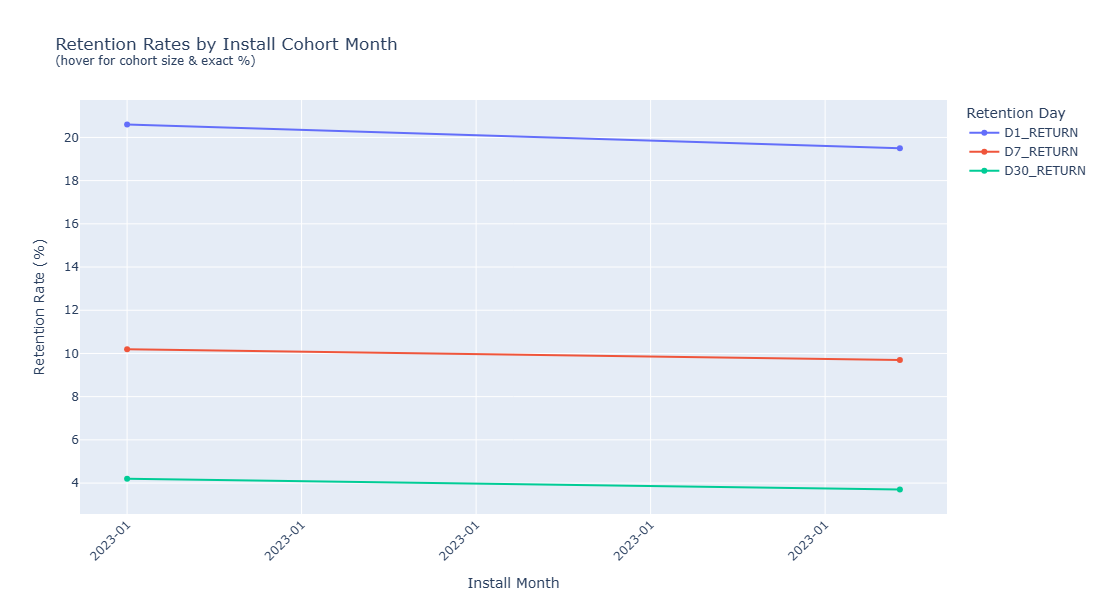

In [12]:
df_melt = cohort_table.melt(
    id_vars=['cohort_month', 'cohort_size'],
    value_vars=['d1_return_pct', 'd7_return_pct', 'd30_return_pct'],
    var_name='Retention Type',
    value_name='Retention %'
)

df_melt['Retention Type'] = df_melt['Retention Type'].str.replace('_pct', '').str.upper()

fig = px.line(
    df_melt,
    x='cohort_month',
    y='Retention %',
    color='Retention Type',
    markers=True,
    title='Retention Rates by Install Cohort Month<br><sup>(hover for cohort size & exact %)</sup>',
    labels={'cohort_month': 'Install Month', 'Retention %': 'Retention Rate (%)'},
    hover_data=['cohort_size']
)

fig.update_traces(
    mode='lines+markers',
    hovertemplate='Month: %{x}<br>Type: %{fullData.name}<br>Retention: %{y:.1f}%<br>Cohort size: %{customdata:,}<extra></extra>'
)

fig.update_layout(
    height=600,
    hovermode='x unified',
    xaxis_tickangle=-45,
    legend_title_text='Retention Day',
    font=dict(size=12),
    xaxis=dict(tickformat='%Y-%m')
)

fig.show()

#### Key Cohort Insights (50,000 players – Jan–Feb 2023 cohorts)

**Retention performance summary**  
- **D1 return** → 19.5–20.6% (average ~20.1%)  
  → ~10,228 players return the next day  
- **D7 return** → 9.7–10.2% (average ~10.0%)  
  → ~5,077 players still active after one week  
- **D30 return** → 3.7–4.2% (average ~4.0%)  
  → ~2,079 players remain after 30 days  

**Survival rates between stages**  
- D1 → D7 survival: **~47–50%** (roughly half of D1 returners survive to D7)  
- D7 → D30 survival: **~36–41%** (strong decay in weeks 2–4)  
  → ~55–64% of D7 returners are lost before D30

**Trend comparison (Jan 2023 vs Feb 2023)**  
- D1 retention slightly down (20.6% → 19.5%)  
- D7 retention down 0.5 pp (10.2% → 9.7%)  
- D30 retention down 0.5 pp (4.2% → 3.7%)  
→ Early signs of retention erosion in newer cohort (Feb) — worth monitoring

**Quantitative impact of improvements**  
- If D7 retention increases by **+3 pp** (from ~10% to 13%) → +1,500 more D7 players  
- If D7 → D30 survival improves by **+15 pp** (from 40% to 55%) → D30 retention could reach **5.5–6.5%** → **+750–1,000** long-term active players

**Top opportunities & recommendations**

1. **Reduce D7 → D30 decay** (highest relative loss: 55–64%)  
   → Weekly login streaks, mid-game events, re-engagement pushes  
   → Target: +10–15 pp survival → major LTV boost

2. **Strengthen D1 return** (currently 20%)  
   → Day-1 rewards, push notifications, easy re-entry mechanics  
   → Target: +5 pp → +2,500 more D1 returners

3. **Monitor cohort trends**  
   → Recent decline (Jan → Feb) suggests possible onboarding fatigue  
   → Track monthly D7/D30 closely — act early if trend continues

**Overall verdict**  
Retention is stable but modest (10% D7, ~4% D30) — typical for mid-tier casual games.  
The largest opportunity lies in **mid-term survival** (D7 → D30) — improving this stage alone could significantly lift lifetime value.